Sampling frequency : 8000 Hz
Samples per signal  : 8000
Pipe length (L)     : 150.0 m
Attenuation (alpha) : 0.01 1/m
Total samples : 900
label
leak           300
consumption    300
other          300
Name: count, dtype: int64
Saved: ../data/signals.npz
Saved: ../data/labels.csv
Saved: ../results/figures/example_waveforms.png and example_waveforms.pdf


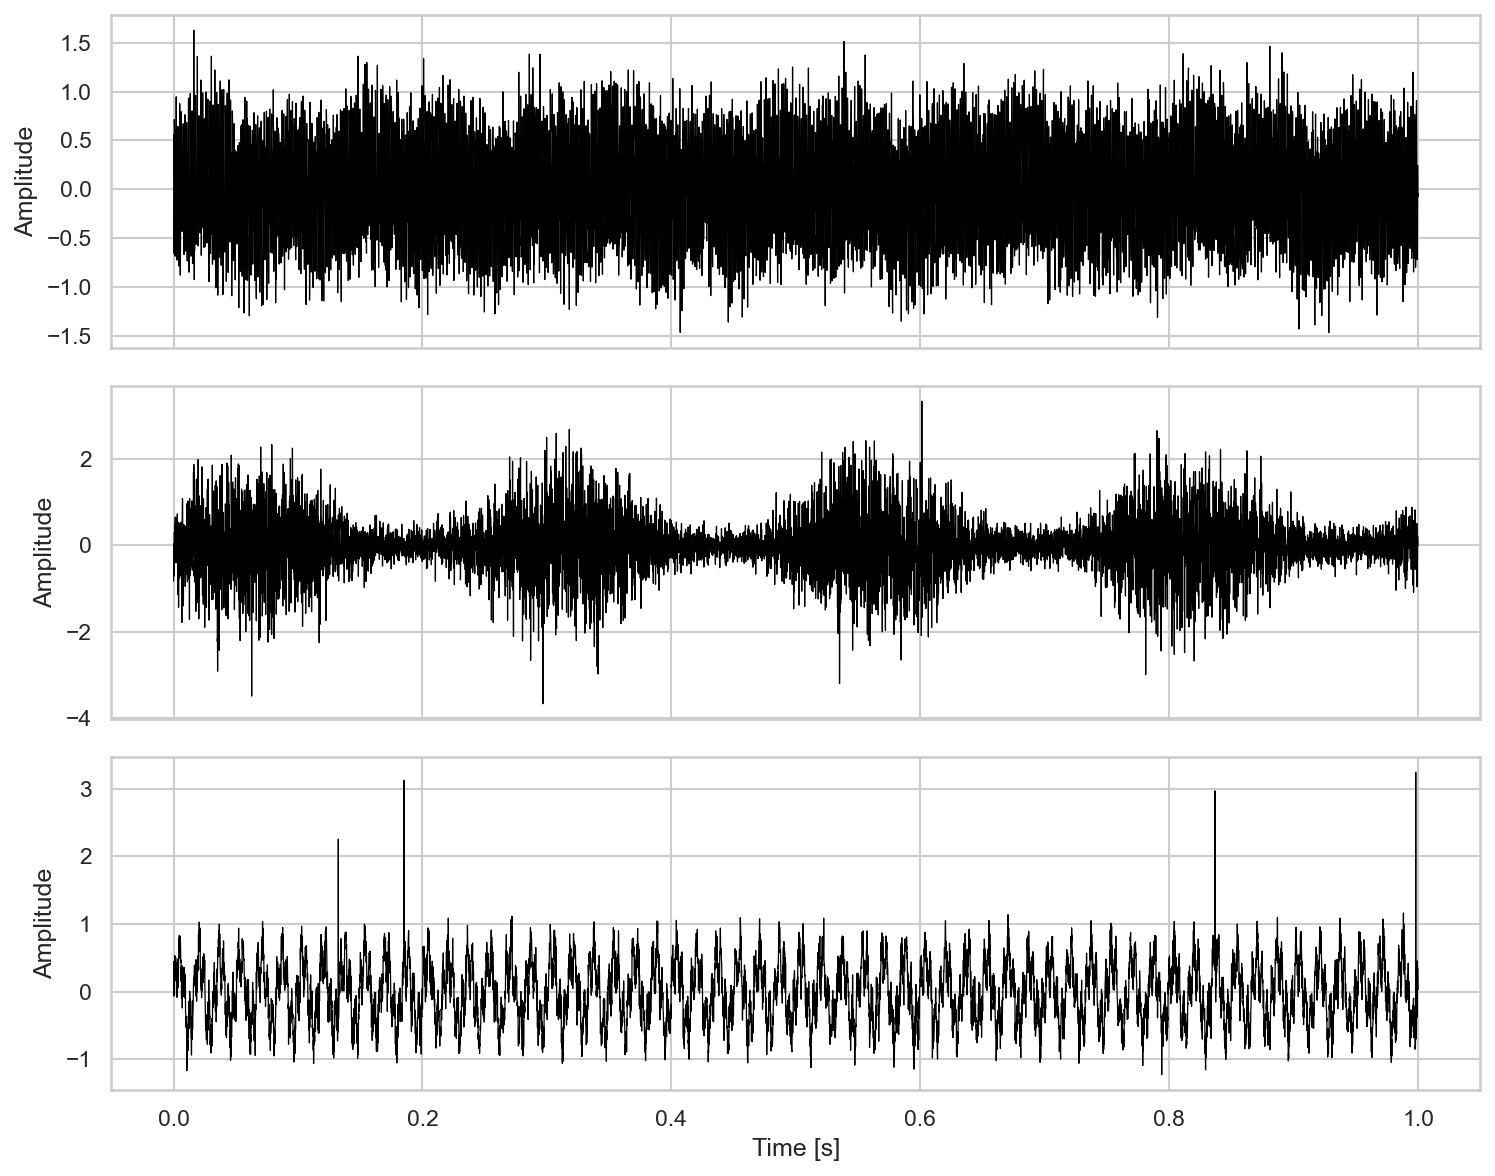

In [2]:
# ============================================================
# Notebook: 01_signal_generation.ipynb
# Purpose : Generate physics-based synthetic acoustic signals for
#           pipeline leak detection/localization simulation.
#           The exponential attenuation model is embedded directly
#           into signal generation so that ground-truth leak
#           positions are fully controlled and known.
# Outputs : ../data/signals.npz          (time-series signals + metadata)
#           ../data/labels.csv           (class labels per sample)
#           ../results/figures/          (example waveform figures)
# ============================================================

# ------------------------------------------------------------
# Cell 1 — Imports and global configuration
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: fix the random seed for the whole notebook
SEED = 42
rng = np.random.default_rng(SEED)

# Directory paths (relative to notebooks/)
DATA_DIR = "../data"
FIG_DIR = "../results/figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Global plotting style: seaborn, grayscale
sns.set_theme(style="whitegrid")
sns.set_palette("gray")
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.dpi"] = 150   # on-screen preview only

# Helper: save a figure as both PNG and PDF at 600 dpi, no title/caption
def save_figure(fig, name, fig_dir=FIG_DIR, dpi=600):
    for ext in ("png", "pdf"):
        path = os.path.join(fig_dir, f"{name}.{ext}")
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {fig_dir}/{name}.png and {name}.pdf")

# Signal acquisition parameters
FS = 8000            # sampling frequency [Hz]
DURATION = 1.0       # signal duration [s]
N_SAMPLES = int(FS * DURATION)
t = np.linspace(0, DURATION, N_SAMPLES, endpoint=False)

# Physical model parameters
PIPE_LENGTH = 150.0  # distance between measurement points A and B [m]
ALPHA = 0.01         # acoustic attenuation coefficient [1/m]

# Number of samples per class
N_PER_CLASS = 300

print(f"Sampling frequency : {FS} Hz")
print(f"Samples per signal  : {N_SAMPLES}")
print(f"Pipe length (L)     : {PIPE_LENGTH} m")
print(f"Attenuation (alpha) : {ALPHA} 1/m")


# ------------------------------------------------------------
# Cell 2 — Source signal generators for each acoustic class
# ------------------------------------------------------------
# Leak sound: quasi-stationary narrow-band signal (dominant leak
# frequency band) plus harmonics. Modeled as a sum of sinusoids in
# a characteristic band with small random frequency jitter.
def generate_leak_source(rng):
    base_freq = rng.uniform(400, 800)          # dominant leak band [Hz]
    signal = np.zeros(N_SAMPLES)
    for k in range(1, 4):                       # a few harmonics
        freq = base_freq * k + rng.normal(0, 5)
        amp = 1.0 / k
        phase = rng.uniform(0, 2 * np.pi)
        signal += amp * np.sin(2 * np.pi * freq * t + phase)
    return signal

# Consumption (water-use) sound: broadband, non-stationary bursts
# (e.g., tap/appliance use). Modeled as amplitude-modulated noise.
def generate_consumption_source(rng):
    noise = rng.normal(0, 1, N_SAMPLES)
    # slow amplitude modulation to create burst-like envelope
    env = 0.5 * (1 + np.sin(2 * np.pi * rng.uniform(1, 4) * t))
    return noise * env

# Other sound: mixed interference (human voice-like low freq +
# electrical hum + scratching). Modeled as low-frequency tones plus
# occasional impulsive spikes.
def generate_other_source(rng):
    hum = 0.5 * np.sin(2 * np.pi * 60 * t)      # electrical hum ~60 Hz
    voice = 0.3 * np.sin(2 * np.pi * rng.uniform(100, 300) * t)
    signal = hum + voice
    # add sparse impulsive spikes (scratching)
    n_spikes = rng.integers(3, 8)
    idx = rng.integers(0, N_SAMPLES, size=n_spikes)
    signal[idx] += rng.uniform(2, 4, size=n_spikes)
    return signal


# ------------------------------------------------------------
# Cell 3 — Exponential attenuation model
# ------------------------------------------------------------
# Energy of a leak signal decays exponentially with propagation
# distance:  E(x) = E0 * exp(-alpha * x).
# A source signal measured at distance x is scaled in amplitude by
# exp(-alpha * x / 2), because energy is proportional to amplitude^2.
def apply_attenuation(source_signal, distance, alpha=ALPHA):
    amplitude_factor = np.exp(-alpha * distance / 2.0)
    return source_signal * amplitude_factor

# Additive measurement noise controlled by a target SNR [dB].
def add_noise(signal, snr_db, rng):
    sig_power = np.mean(signal ** 2)
    if sig_power == 0:
        return signal
    snr_linear = 10 ** (snr_db / 10.0)
    noise_power = sig_power / snr_linear
    noise = rng.normal(0, np.sqrt(noise_power), size=signal.shape)
    return signal + noise


# ------------------------------------------------------------
# Cell 4 — Build the dataset
# ------------------------------------------------------------
# For each sample we store:
#   - signal_A, signal_B : signals measured at points A and B
#   - label              : 'leak' / 'consumption' / 'other'
#   - x_true             : true leak position measured from A (leak only)
#   - E_A, E_B           : measured acoustic energies at A and B
#   - alpha              : attenuation coefficient used
#
# For non-leak classes there is no localization target, so x_true is
# set to NaN and the same source is measured at both points with
# independent noise (no propagation geometry).

records = []
signals_A = []
signals_B = []

def measured_energy(signal):
    return float(np.mean(signal ** 2))

# ---- Leak samples ----
for i in range(N_PER_CLASS):
    source = generate_leak_source(rng)
    x_true = rng.uniform(10, PIPE_LENGTH - 10)     # true leak position from A
    xA = x_true                                    # distance leak -> A
    xB = PIPE_LENGTH - x_true                      # distance leak -> B
    snr_db = rng.uniform(5, 20)

    sigA = add_noise(apply_attenuation(source, xA), snr_db, rng)
    sigB = add_noise(apply_attenuation(source, xB), snr_db, rng)

    signals_A.append(sigA)
    signals_B.append(sigB)
    records.append({
        "id": len(records),
        "label": "leak",
        "x_true": x_true,
        "E_A": measured_energy(sigA),
        "E_B": measured_energy(sigB),
        "alpha": ALPHA,
        "snr_db": snr_db,
    })

# ---- Consumption samples ----
for i in range(N_PER_CLASS):
    source = generate_consumption_source(rng)
    snr_db = rng.uniform(5, 20)
    sigA = add_noise(source, snr_db, rng)
    sigB = add_noise(source, snr_db, rng)
    signals_A.append(sigA)
    signals_B.append(sigB)
    records.append({
        "id": len(records),
        "label": "consumption",
        "x_true": np.nan,
        "E_A": measured_energy(sigA),
        "E_B": measured_energy(sigB),
        "alpha": ALPHA,
        "snr_db": snr_db,
    })

# ---- Other samples ----
for i in range(N_PER_CLASS):
    source = generate_other_source(rng)
    snr_db = rng.uniform(5, 20)
    sigA = add_noise(source, snr_db, rng)
    sigB = add_noise(source, snr_db, rng)
    signals_A.append(sigA)
    signals_B.append(sigB)
    records.append({
        "id": len(records),
        "label": "other",
        "x_true": np.nan,
        "E_A": measured_energy(sigA),
        "E_B": measured_energy(sigB),
        "alpha": ALPHA,
        "snr_db": snr_db,
    })

signals_A = np.array(signals_A)
signals_B = np.array(signals_B)
labels_df = pd.DataFrame(records)

print(f"Total samples : {len(labels_df)}")
print(labels_df["label"].value_counts())


# ------------------------------------------------------------
# Cell 5 — Save signals and labels
# ------------------------------------------------------------
np.savez_compressed(
    os.path.join(DATA_DIR, "signals.npz"),
    signals_A=signals_A,
    signals_B=signals_B,
    fs=FS,
    t=t,
    pipe_length=PIPE_LENGTH,
    alpha=ALPHA,
)
labels_df.to_csv(os.path.join(DATA_DIR, "labels.csv"), index=False)

print("Saved: ../data/signals.npz")
print("Saved: ../data/labels.csv")


# ------------------------------------------------------------
# Cell 6 — Plot one example signal per class (sanity check)
# ------------------------------------------------------------
# Grayscale line plots, no titles/captions. Each subplot is one class.
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, cls in zip(axes, ["leak", "consumption", "other"]):
    idx = labels_df.index[labels_df["label"] == cls][0]
    ax.plot(t, signals_A[idx], linewidth=0.6, color="black")
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
save_figure(fig, "example_waveforms")
plt.show()